Lucas Henrique Nogueira - 202265515B

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Funções de Elementos Finitos Auxiliares

# Retorna os graus de liberdade do elemento.
def feeldof(nd, nnel, ndof):
    index = []
    for i in range(nnel):
        start = nd[i] * ndof
        for j in range(ndof):
            index.append(start + j)
    return np.array(index, dtype=int)

# Monta a Matriz Cinemática (B).
def fekine2d(nnel, dhdx, dhdy):
    kinmtx2 = np.zeros((3, nnel * 2))
    for i in range(nnel):
        i1 = i * 2
        i2 = i1 + 1
        kinmtx2[0, i1] = dhdx[i]
        kinmtx2[0, i2] = 0
        kinmtx2[1, i1] = 0
        kinmtx2[1, i2] = dhdy[i]
        kinmtx2[2, i1] = dhdy[i]
        kinmtx2[2, i2] = dhdx[i]
    return kinmtx2

# Monta a Matriz Constitutiva (D).
def fematiso(iopt, elastic, poisson):
    if iopt == 1:
        factor = elastic / (1 - poisson**2)
        matmtrx = factor * np.array([
            [1, poisson, 0],
            [poisson, 1, 0],
            [0, 0, (1 - poisson)/2]])
    else:
        matmtrx = np.zeros((3,3)) 
    return matmtrx

# Montagem da matriz global.
def feasmbl1(kk, k, index):
    edof = len(index)
    for i in range(edof):
        ii = index[i]
        for j in range(edof):
            jj = index[j]
            kk[ii, jj] += k[i, j]
    return kk

# Aplica condições de contorno.
def feaplyc2(kk, ff, bcdof, bcval):
    n = len(bcdof)
    sdof = kk.shape[0]
    for i in range(n):
        c = bcdof[i]
        for j in range(sdof):
            kk[c, j] = 0.0
        kk[c, c] = 1.0
        ff[c] = bcval[i]
    return kk, ff

In [13]:
def plot_results(gcoord, nodes, disp, title, scale_factor=500000):

    plt.figure(figsize=(10, 5))
    plt.title(f"{title} - Escala de Deformação x{scale_factor}")
    
    nel = nodes.shape[0]
    
    for i in range(nel):
        nd = nodes[i, :]
        x_orig = gcoord[nd, 0]
        y_orig = gcoord[nd, 1]

        x_orig_plot = np.append(x_orig, x_orig[0])
        y_orig_plot = np.append(y_orig, y_orig[0])
        
        dx = np.array([disp[2*n] for n in nd])
        dy = np.array([disp[2*n+1] for n in nd])
        
        x_def = x_orig + dx * scale_factor
        y_def = y_orig + dy * scale_factor
        
        x_def_plot = np.append(x_def, x_def[0])
        y_def_plot = np.append(y_def, y_def[0])
        
        plt.plot(x_orig_plot, y_orig_plot, 'k--', linewidth=0.5, alpha=0.5) 
        plt.plot(x_def_plot, y_def_plot, 'b-', linewidth=1.5) 
        
    plt.legend(['Original', 'Deformada'], loc='best')

    nnode = gcoord.shape[0]
    for i in range(nnode):
        x = gcoord[i, 0]
        y = gcoord[i, 1]
        
        dx_node = disp[2*i] * scale_factor
        dy_node = disp[2*i+1] * scale_factor
        
        label = str(i) 
        
        plt.text(x + dx_node, y + dy_node, label, 
                 fontsize=12, color='red', weight='bold', zorder=5,
                 bbox=dict(facecolor='white', alpha=0.1, edgecolor='none', pad=1))

    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.grid(True)
    plt.axis('equal')
    plt.savefig(f"{title.replace(' ', '_').lower()}_deformada.png", dpi=600, bbox_inches='tight')
    plt.show()

In [14]:
# Solver
def resolver_caso(nome_caso, gcoord, nodes, carga_distribuida_nodes, forca_pontual_node):
    
    # Dados Físicos
    emodule = 200000000.0 
    poisson = 0.3
    thickness = 1.0 
    
    nel = nodes.shape[0]     
    nnode = gcoord.shape[0]  
    nnel = 3                 
    ndof = 2                 
    sdof = nnode * ndof      
    edof = nnel * ndof       

    # Inicialização 
    ff = np.zeros(sdof)
    kk = np.zeros((sdof, sdof))
    disp = np.zeros(sdof)
    
    # Forças 
    for no, valor in carga_distribuida_nodes:
        ff[2 * no] += valor
        
    # Pontual F = 10kN (para baixo Y)
    if forca_pontual_node is not None:
        ff[2 * forca_pontual_node + 1] -= 10.0 
    
    # Montagem 
    matmtx = fematiso(1, emodule, poisson) 

    for iel in range(nel):
        nd = nodes[iel, :]
        x1, y1 = gcoord[nd[0], 0], gcoord[nd[0], 1]
        x2, y2 = gcoord[nd[1], 0], gcoord[nd[1], 1]
        x3, y3 = gcoord[nd[2], 0], gcoord[nd[2], 1]
        
        index = feeldof(nd, nnel, ndof)
        
        area = 0.5 * (x1*y2 + x2*y3 + x3*y1 - x1*y3 - x2*y1 - x3*y2)
        area = abs(area) 
        area2 = area * 2.0
        
        dhdx = (1.0/area2) * np.array([y2-y3, y3-y1, y1-y2])
        dhdy = (1.0/area2) * np.array([x3-x2, x1-x3, x2-x1])
        
        kinmtx2 = fekine2d(nnel, dhdx, dhdy)
        k = kinmtx2.T @ matmtx @ kinmtx2 * area * thickness
        kk = feasmbl1(kk, k, index)

    # Condições de Contorno (Engaste X=0)
    bcdof = []
    bcval = []
    for i in range(nnode):
        if gcoord[i, 0] == 0.0: 
            bcdof.append(2*i)     
            bcdof.append(2*i + 1) 
            bcval.append(0.0)
            bcval.append(0.0)
            
    kk, ff = feaplyc2(kk, ff, np.array(bcdof), np.array(bcval))

    # Resolução
    disp = np.linalg.solve(kk, ff)

    print(f"RESULTADOS: {nome_caso}")
    print(f"{'Nó':<5} {'Desloc X (m)':<15} {'Desloc Y (m)':<15}")
    for i in range(nnode):
        print(f"{i:<5} {disp[2*i]:.6e}    {disp[2*i+1]:.6e}")
        
    print("\nTENSÕES (kN/m^2):")
    print(f"{'Elem':<5} {'Sigma_x':<15} {'Sigma_y':<15} {'Tau_xy':<15}")
    
    for ielp in range(nel):
        nd = nodes[ielp, :]
        x1, y1 = gcoord[nd[0], 0], gcoord[nd[0], 1]
        x2, y2 = gcoord[nd[1], 0], gcoord[nd[1], 1]
        x3, y3 = gcoord[nd[2], 0], gcoord[nd[2], 1]
        
        index = feeldof(nd, nnel, ndof)
        eldisp = np.zeros(edof)
        for i in range(edof):
            eldisp[i] = disp[index[i]]
            
        area = 0.5 * (x1*y2 + x2*y3 + x3*y1 - x1*y3 - x2*y1 - x3*y2)
        area = abs(area)
        area2 = area * 2.0
        dhdx = (1.0/area2) * np.array([y2-y3, y3-y1, y1-y2])
        dhdy = (1.0/area2) * np.array([x3-x2, x1-x3, x2-x1])
        kinmtx2 = fekine2d(nnel, dhdx, dhdy)
        
        estrain = kinmtx2 @ eldisp
        estress = matmtx @ estrain
        print(f"{ielp+1:<5} {estress[0]:.4e}    {estress[1]:.4e}    {estress[2]:.4e}")
    
    plot_results(gcoord, nodes, disp, nome_caso)

RESULTADOS: 3 ELEMENTOS
Nó    Desloc X (m)    Desloc Y (m)   
0     -1.994023e-22    2.014610e-22
1     8.504624e-08    -2.129949e-07
2     1.590866e-07    -2.278172e-07
3     -7.115961e-24    0.000000e+00
4     9.590899e-08    -1.419743e-07

TENSÕES (kN/m^2):
Elem  Sigma_x         Sigma_y         Tau_xy         
1     1.7517e+00    -1.2483e+00    -1.0214e+00
2     3.2270e+00    2.2697e-01    -2.2697e-01
3     5.2697e+00    1.5809e+00    -2.7303e+00


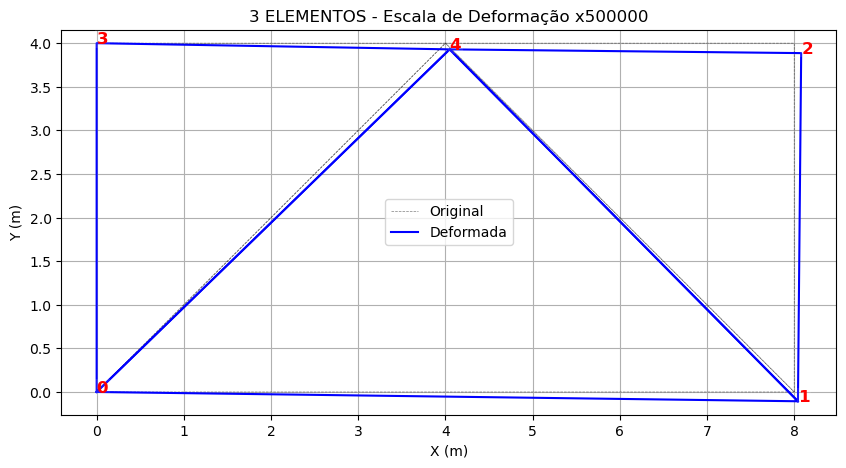

RESULTADOS: 4 ELEMENTOS
Nó    Desloc X (m)    Desloc Y (m)   
0     -4.212567e-23    3.559155e-22
1     3.244446e-08    -1.418114e-07
2     9.169057e-08    -2.029894e-07
3     -2.727965e-22    9.631420e-23
4     8.562190e-08    -1.713660e-07
5     1.500683e-07    -2.217433e-07

TENSÕES (kN/m^2):
Elem  Sigma_x         Sigma_y         Tau_xy         
1     1.2955e+00    -1.0891e+00    -1.7045e+00
2     4.7045e+00    1.4114e+00    -3.2955e+00
3     2.9462e+00    -5.3849e-02    -5.3849e-02
4     3.0538e+00    -5.6157e-01    5.3849e-02


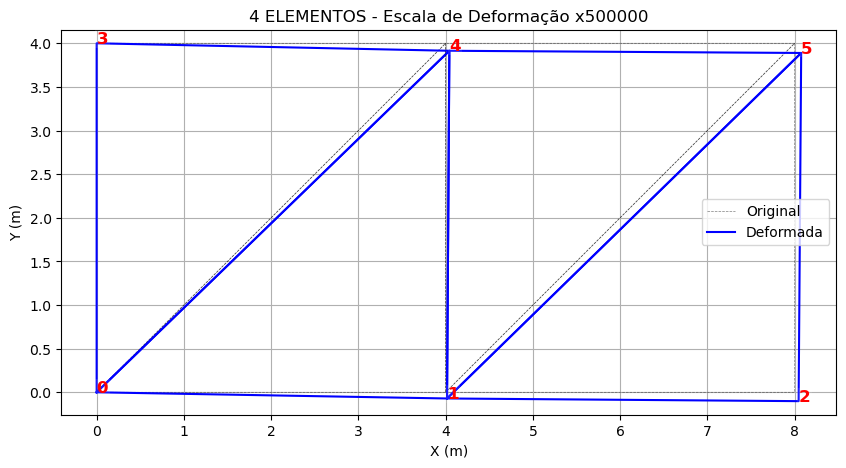

RESULTADOS: 8 ELEMENTOS
Nó    Desloc X (m)    Desloc Y (m)   
0     4.443537e-23    -1.005925e-20
1     -1.789476e-09    -7.482580e-08
2     2.417052e-08    -1.554756e-07
3     5.341906e-08    -2.026561e-07
4     8.347286e-08    -2.429071e-07
5     3.470812e-21    1.261813e-20
6     5.791994e-08    -8.502891e-08
7     9.469337e-08    -1.994953e-07
8     1.301398e-07    -2.259365e-07
9     1.611767e-07    -2.628979e-07

TENSÕES (kN/m^2):
Elem  Sigma_x         Sigma_y         Tau_xy         
1     -3.6483e-01    -6.1960e-01    -1.7297e+00
2     6.3648e+00    1.9094e+00    -3.2703e+00
3     2.1271e+00    -1.5628e+00    -1.7457e+00
4     3.8729e+00    6.5170e-01    -3.2543e+00
5     2.8304e+00    -3.1491e-01    -3.3924e-01
6     3.1696e+00    -1.2501e+00    3.3924e-01
7     2.9731e+00    -1.0762e-01    -5.3808e-02
8     3.0269e+00    -2.5595e-01    5.3808e-02


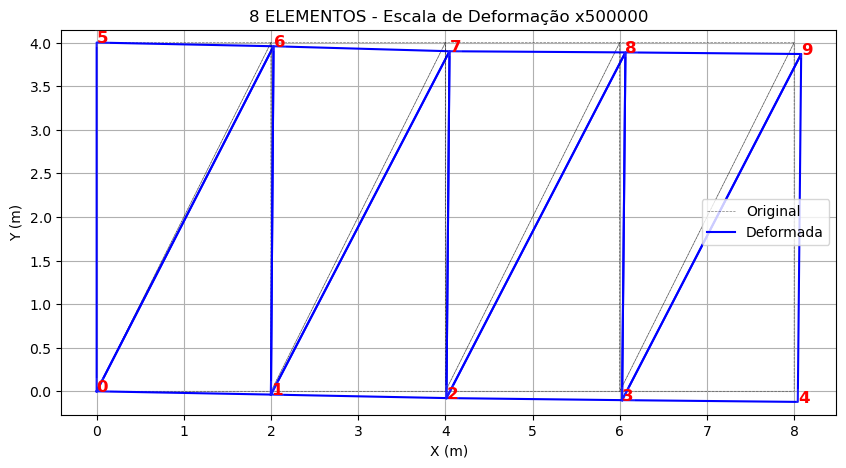

In [ ]:
# Execução
if __name__ == "__main__":
    # Carga total 12kN na borda. Elementos lineares = 6kN por nó da borda.
    load_q = 6.0 

    # Caso: 3 ELEMENTOS 
    gcoord_3 = np.array([[0.,0.], [8.,0.], [8.,4.], [0.,4.], [4.,4.]])
    nodes_3 = np.array([[0,1,4], [1,2,4], [0,4,3]], dtype=int)
    q_nodes_3 = [(1, load_q), (2, load_q)]
    resolver_caso("3 ELEMENTOS", gcoord_3, nodes_3, q_nodes_3, 4)

    # Caso: 4 ELEMENTOS 
    gcoord_4 = np.array([[0.,0.], [4.,0.], [8.,0.], [0.,4.], [4.,4.], [8.,4.]])
    nodes_4 = np.array([[0,1,4], [0,4,3], [1,2,5], [1,5,4]], dtype=int)
    q_nodes_4 = [(2, load_q), (5, load_q)]
    resolver_caso("4 ELEMENTOS", gcoord_4, nodes_4, q_nodes_4, 4)

    # Caso: 8 ELEMENTOS 
    gcoord_8 = np.array([[0.,0.], [2.,0.], [4.,0.], [6.,0.], [8.,0.], [0.,4.], [2.,4.], [4.,4.], [6.,4.], [8.,4.]])
    nodes_8 = np.array([[0,1,6], [0,6,5], [1,2,7], [1,7,6], [2,3,8], [2,8,7], [3,4,9], [3,9,8]], dtype=int)
    q_nodes_8 = [(4, load_q), (9, load_q)]
    resolver_caso("8 ELEMENTOS", gcoord_8, nodes_8, q_nodes_8, 7)